In [15]:
!git clone https://github.com/rashibharti28/BERT-Quantization-PTQ-QAT-on-dair-ai-emotion.git

fatal: destination path 'BERT-Quantization-PTQ-QAT-on-dair-ai-emotion' already exists and is not an empty directory.


In [16]:
finetune_model_dir = "/content/BERT-Quantization-PTQ-QAT-on-dair-ai-emotion/finetuning_bert"


In [17]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns



In [18]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)



In [19]:
ds = load_dataset("dair-ai/emotion", "split")

In [20]:
test = ds['test']
tokenizer = AutoTokenizer.from_pretrained(ptq_model_path)
def tokenize_batch(batch, tokenizer):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )


tokenized_test = test.map(lambda x: tokenize_batch(x, tokenizer), batched=True)
tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print(tokenized_test)


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 2000
})


In [21]:
ft_model = AutoModelForSequenceClassification.from_pretrained(finetune_model_dir)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ft_model = ft_model.to(device)
ft_model.eval()

print("Fine-tuned model loaded")
print(f"Model type: {type(ft_model)}")

Fine-tuned model loaded
Model type: <class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'>


In [22]:
test_loader = DataLoader(tokenized_test, batch_size=16)
predictions, labels = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        inputs = {
            "input_ids": batch["input_ids"].to(device),
            "attention_mask": batch["attention_mask"].to(device)
        }
        outputs = ft_model(**inputs)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        labels.extend(batch["label"].numpy())
        predictions.extend(preds)


Evaluating: 100%|██████████| 125/125 [00:07<00:00, 17.67it/s]


In [23]:
import torch
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import time

def compute_classification_metrics(predictions, labels, num_classes):
    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")
    per_class_f1 = f1_score(labels, predictions, average=None, labels=range(num_classes))
    cm = confusion_matrix(labels, predictions, labels=range(num_classes))

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "per_class_f1": per_class_f1,
        "confusion_matrix": cm
    }


def get_model_size(model):
    """Return model size in MB"""
    torch.save(model.state_dict(), "temp.pth")
    size_mb = os.path.getsize("temp.pth") / (1024 * 1024)
    os.remove("temp.pth")
    return size_mb


def measure_latency(model, dataset, num_samples=50):
    """Measure average inference time per sample"""
    model.eval()
    total = 0
    with torch.no_grad():
        for i in range(min(num_samples, len(dataset))):
            inputs = {k: dataset[i][k].unsqueeze(0).to(model.device)
                      for k in ["input_ids", "attention_mask"]}

            start = time.time()
            _ = model(**inputs)
            end = time.time()

            total += (end - start)

    return (total / num_samples) * 1000


In [24]:
def summarize_evaluation(
    model,
    dataset,
    predictions,
    labels,
    model_name="Model",
    num_classes=6,
    class_names=["sadness", "joy", "love", "anger", "fear", "surprise"]
):

    print(f"\n{model_name} Evaluation Summary\n{'='*60}")

    metrics = compute_classification_metrics(predictions, labels, num_classes)
    model_size = get_model_size(model)
    latency = measure_latency(model, dataset)

    print(f"Accuracy:       {metrics['accuracy']:.4f}")
    print(f"Macro F1:       {metrics['macro_f1']:.4f}")
    print(f"Model Size:     {model_size:.2f} MB")
    print(f"Latency:        {latency:.2f} ms/sample\n")

    print("Classification Report:")
    print(classification_report(labels, predictions, target_names=class_names, digits=3))

    print("\nPer-Class F1 Scores:")
    for i, f1_score in enumerate(metrics["per_class_f1"]):
        label_name = class_names[i]
        print(f"  {label_name:<15}: {f1_score:.4f}")

    cm = np.array(metrics["confusion_matrix"])
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    return metrics



DistilBERT Fine-tuned (FP32) Evaluation Summary
Accuracy:       0.9265
Macro F1:       0.8828
Model Size:     255.46 MB
Latency:        4.02 ms/sample

Classification Report:
              precision    recall  f1-score   support

     sadness      0.984     0.950     0.967       581
         joy      0.938     0.961     0.950       695
        love      0.877     0.761     0.815       159
       anger      0.918     0.931     0.924       275
        fear      0.877     0.893     0.885       224
    surprise      0.683     0.848     0.757        66

    accuracy                          0.926      2000
   macro avg      0.879     0.891     0.883      2000
weighted avg      0.929     0.926     0.927      2000


Per-Class F1 Scores:
  sadness        : 0.9667
  joy            : 0.9495
  love           : 0.8148
  anger          : 0.9242
  fear           : 0.8850
  surprise       : 0.7568


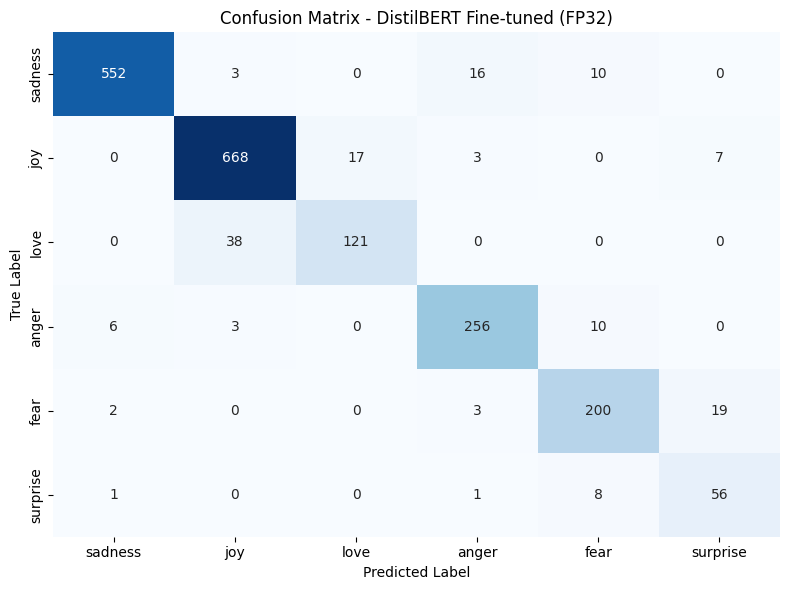

In [25]:
results = summarize_evaluation(
    model=ft_model,
    dataset=tokenized_test,
    predictions=predictions,
    labels=labels,
    model_name="DistilBERT Fine-tuned (FP32)",
    num_classes=6
)

